In [2]:
import pickle, gzip
from pyrosm import OSM
import osmnx as ox
import networkx as nx
import os
os.environ['USE_PYGEOS'] = '0'

In [7]:
# if os.uname().sysname == "Windows":
#     current_dir = os.path.basename(os.getcwd())
    
#     if current_dir != "backend":
#         os.chdir(os.path.join(os.getcwd(), "backend"))

In [10]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\qshah\\Documents\\Fall 2026\\scout\\backend'

In [8]:
city = 'chicago'

In [15]:
pbf_path = "./data/%s.osm.pbf" % city
osm = OSM(pbf_path)

In [16]:
# Get driving network with nodes=True
nodes_gdf, edges_gdf = osm.get_network(
    network_type="driving",
    nodes=True,  
    extra_attributes=["maxspeed", "lanes", "name", "oneway"]
)

In [17]:
# Build MultiDiGraph
G = nx.MultiDiGraph()

# add nodes
for _, row in nodes_gdf.iterrows():
    nid = int(row["id"])
    # OSMnx convention: x = lon, y = lat
    G.add_node(
        nid,
        x=float(row["lon"]),
        y=float(row["lat"]),
        # keep anything else if you care
        # timestamp=row["timestamp"],
        # visible=row["visible"],
    )

# add edges
for _, row in edges_gdf.iterrows():
    u = int(row["u"])
    v = int(row["v"])

    # copy all edge attributes except u,v
    data = row.to_dict()
    data.pop("u", None)
    data.pop("v", None)

    # pyrosm typically already gives 'length' (in meters) and 'geometry'
    G.add_edge(u, v, **data)

In [18]:
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

Nodes: 637237 Edges: 741271


In [19]:
G.graph["crs"] = "EPSG:4326"

In [20]:
# add speeds & travel times via OSMnx
G = ox.add_edge_speeds(G)        # adds edge attribute 'speed_kph'
G = ox.add_edge_travel_times(G)  # adds edge attribute 'travel_time' (seconds)

# convert to geodataframe
edges = ox.convert.graph_to_gdfs(G, nodes=False, edges=True)

In [21]:
edges = edges[['length', 'speed_kph', 'travel_time', 'geometry', 'width', 'name']]

In [22]:
# Save
edges.to_feather('data/%s/roads.feather' % city, compression='lz4')

In [23]:
# Save
with gzip.open("./data/%s/roads.pkl.gz" % city, "wb") as f:
    pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

In [24]:
# For server side: cropping example

with gzip.open("./data/%s/roads.pkl.gz" % city, "rb") as f:
    G = pickle.load(f)

maxx, minx, maxy, miny = -87.65, -87.75, 41.66, 41.64  # bbox
nodes, _ = ox.graph_to_gdfs(G, nodes=True, edges=True, fill_edge_geometry=False)

mask = (
    (nodes["y"] <= maxy) & (nodes["y"] >= miny) &
    (nodes["x"] <= maxx) & (nodes["x"] >= minx)
)
node_ids = nodes.loc[mask].index
G_crop = G.subgraph(node_ids)

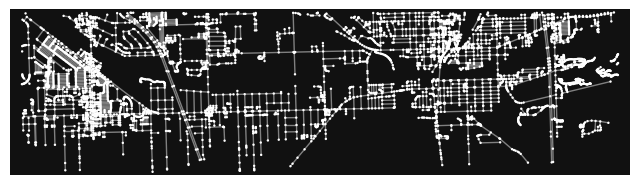

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [25]:
ox.plot_graph(G_crop, node_size=3, edge_color="gray")